# Анализ SCORE_* признаков

Цель — исследовать диапазоны значений, тренды по времени и корреляции SCORE_* с целевыми и числовыми признаками.

## 1. Загрузка данных SCORE

Загружаем train.csv, приводим SCORE_* к числовому типу и проверяем типы.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

train_path = "dataset/train.csv"
df = pd.read_csv(train_path, low_memory=False)

if "operation_date" in df.columns:
    df["operation_date"] = pd.to_datetime(df["operation_date"], errors="coerce")

score_cols = [c for c in df.columns if c.startswith("SCORE_")]

for col in score_cols:
    if df[col].dtype == "object":
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("SCORE columns:", len(score_cols))

# Quick type overview
if score_cols:
    display(df[score_cols].dtypes.value_counts())

SCORE columns: 128


float64    128
Name: count, dtype: int64

## 2. Минимум, максимум и описательная статистика

Считаем min/max, средние, медианы и долю пропусков по SCORE_*.

In [6]:
if score_cols:
    score_stats = df[score_cols].agg([
        "min",
        "max",
        "mean",
        "median",
        "std",
    ]).T

    score_stats["missing_pct"] = (df[score_cols].isna().mean() * 100).round(2)
    score_stats = score_stats.sort_values("missing_pct", ascending=False)

    display(score_stats)
else:
    print("No SCORE_* columns found")

,min,max,mean,median,std,missing_pct
SCORE_12_4,1.0,1.0,1.000000,1.0,0.000000,99.95
SCORE_12_6,1.0,1.0,1.000000,1.0,0.000000,99.94
SCORE_12_5,1.0,1.0,1.000000,1.0,0.000000,99.80
SCORE_12_1,1.0,1.0,1.000000,1.0,0.000000,99.69
SCORE_12_2,1.0,1.0,1.000000,1.0,0.000000,99.66
...,...,...,...,...,...,...
SCORE_11_13,0.0,1.0,0.059551,0.0,0.236653,1.31
SCORE_11_14,0.0,1.0,0.072789,0.0,0.259790,1.31
SCORE_8_2,1.0,10.0,2.373862,1.0,2.241570,1.29
SCORE_8_3,1.0,10.0,1.838904,1.0,2.491197,1.29


## 3. Тренды SCORE во времени

Агрегируем по месяцам и строим тренды для наиболее вариативных SCORE.

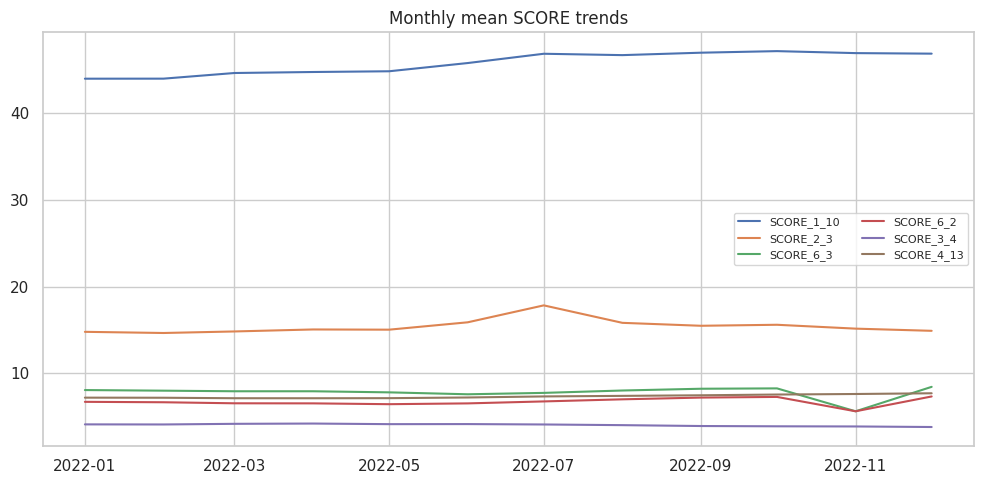

In [3]:
if score_cols and "operation_date" in df.columns:
    score_var = df[score_cols].var(numeric_only=True).sort_values(ascending=False)
    top_scores = score_var.head(6).index.tolist()

    trend_df = df[["operation_date"] + top_scores].copy()
    trend_df = trend_df.dropna(subset=["operation_date"])
    trend_df["month"] = trend_df["operation_date"].dt.to_period("M").dt.to_timestamp()

    monthly = trend_df.groupby("month")[top_scores].mean().reset_index()

    plt.figure(figsize=(10, 5))
    for col in top_scores:
        plt.plot(monthly["month"], monthly[col], label=col)
    plt.title("Monthly mean SCORE trends")
    plt.legend(ncol=2, fontsize=8)
    plt.tight_layout()
else:
    print("operation_date or SCORE_* columns not found")

## 4. Корреляции SCORE с целевыми и числовыми признаками

Считаем корреляции с `is_claim`, `claim_amount`, а также с ключевыми числовыми полями.

,is_claim,claim_amount,premium_wo_term,premium
SCORE_11_1,0.016392,-0.005211,-0.035622,0.006100
SCORE_8_3,0.015665,-0.009184,-0.030427,0.004022
SCORE_8_1,0.014599,-0.010044,-0.054608,-0.016405
SCORE_11_2,0.014118,-0.005215,-0.037179,0.006707
SCORE_2_1,0.013918,0.015274,-0.036930,0.003649
SCORE_8_2,0.013594,-0.018718,-0.035756,-0.004156
SCORE_11_10,0.013306,-0.000026,-0.031471,0.009227
SCORE_4_14,0.013121,-0.016694,0.001153,0.016856
SCORE_11_3,0.012699,-0.012490,-0.037996,0.006920
SCORE_11_4,0.012672,-0.032500,-0.035976,0.007837


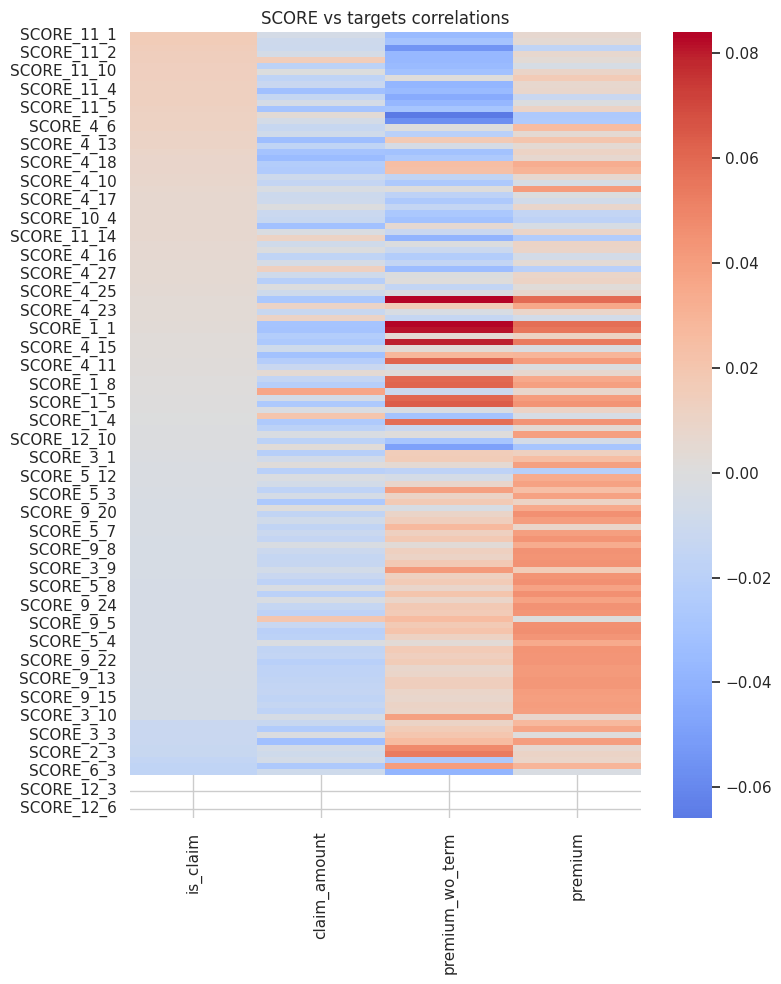

In [4]:
targets = [c for c in ["is_claim", "claim_amount", "premium_wo_term", "premium"] if c in df.columns]

if score_cols and targets:
    corr_df = df[score_cols + targets].corr()
    score_corr = corr_df.loc[score_cols, targets].sort_values(by=targets[0], ascending=False)
    display(score_corr.head(15))

    plt.figure(figsize=(8, 10))
    sns.heatmap(score_corr, cmap="coolwarm", center=0)
    plt.title("SCORE vs targets correlations")
    plt.tight_layout()
else:
    print("No SCORE_* or target columns found")

## 5. Визуализация распределений и связей

Строим гистограммы, boxplot и scatter для нескольких SCORE.

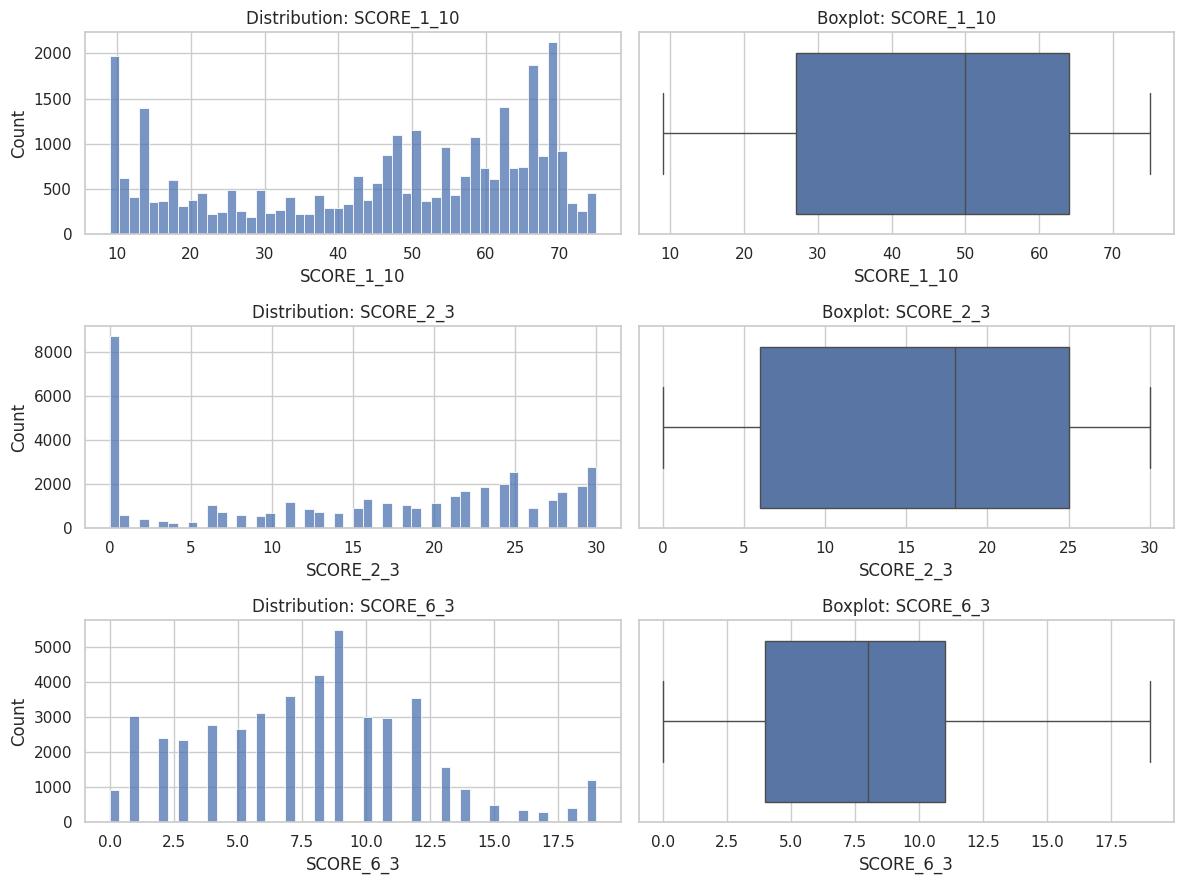

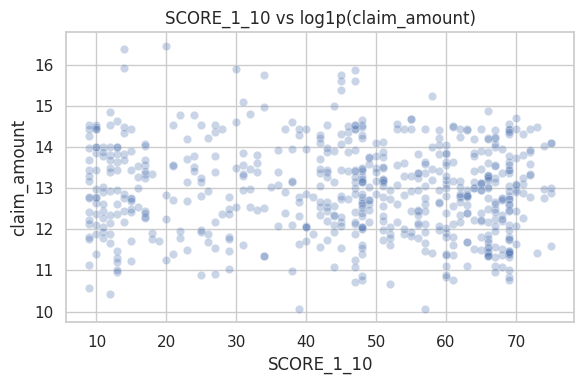

In [5]:
if score_cols:
    score_var = df[score_cols].var(numeric_only=True).sort_values(ascending=False)
    top_scores = score_var.head(3).index.tolist()

    plot_sample = df[top_scores + targets].sample(n=min(50000, len(df)), random_state=42)

    fig, axes = plt.subplots(len(top_scores), 2, figsize=(12, 3 * len(top_scores)))
    if len(top_scores) == 1:
        axes = [axes]

    for i, col in enumerate(top_scores):
        sns.histplot(plot_sample[col], bins=50, ax=axes[i][0])
        axes[i][0].set_title(f"Distribution: {col}")

        sns.boxplot(x=plot_sample[col], ax=axes[i][1])
        axes[i][1].set_title(f"Boxplot: {col}")

    plt.tight_layout()

    if "claim_amount" in targets:
        plt.figure(figsize=(6, 4))
        sns.scatterplot(
            x=plot_sample[top_scores[0]],
            y=np.log1p(plot_sample["claim_amount"]),
            alpha=0.3,
        )
        plt.title(f"{top_scores[0]} vs log1p(claim_amount)")
        plt.tight_layout()
else:
    print("No SCORE_* columns found")

## 6. Группировка SCORE по первому номеру

Объединяем SCORE по первой цифре после `SCORE_` (например, все `SCORE_1_*`, `SCORE_2_*`) и анализируем средние значения и корреляции.

,count,mean,std,min,25%,50%,75%,max
SCORE_G2,481219.0,7.837543,4.350825,0.333333,4.000000,8.666667,11.666667,13.333333
SCORE_G1,360754.0,9.141142,4.143688,1.800000,5.400000,10.000000,12.800000,15.000000
SCORE_G6,516351.0,5.611359,3.349501,0.000000,3.000000,5.333333,7.666667,19.000000
SCORE_G9,557716.0,6.980516,3.074364,1.000000,5.000000,8.041667,9.750000,10.000000
SCORE_G7,199621.0,5.766414,3.047911,0.000000,3.333333,5.333333,7.666667,16.000000
SCORE_G5,509867.0,8.213809,2.408326,1.000000,7.333333,9.166667,10.000000,10.000000
SCORE_G8,562167.0,2.767704,2.214197,1.000000,1.000000,2.000000,3.666667,10.000000
SCORE_G10,508785.0,2.838100,1.847877,1.000000,1.000000,2.500000,4.000000,10.000000
SCORE_G4,432443.0,2.616980,1.176842,1.000000,1.666667,2.433333,3.333333,8.733333
SCORE_G3,458997.0,7.496350,0.908573,3.000000,6.900000,7.600000,8.100000,10.100000


,is_claim,claim_amount,premium_wo_term,premium
SCORE_G8,0.017314,-0.014350,-0.049106,-0.007594
SCORE_G10,0.012904,-0.009672,-0.056597,-0.022172
SCORE_G4,0.009436,-0.024439,-0.001956,0.016681
SCORE_G11,0.008134,0.009009,-0.041083,-0.024629
SCORE_G1,0.002244,-0.026277,0.079522,0.053348
SCORE_G3,-0.001750,-0.014546,0.023889,0.035076
SCORE_G5,-0.003495,-0.004121,0.005880,0.038976
SCORE_G12,-0.004655,0.010769,-0.052764,-0.045768
SCORE_G9,-0.004962,-0.016348,0.014285,0.044743
SCORE_G2,-0.012429,-0.007040,0.052082,0.010147


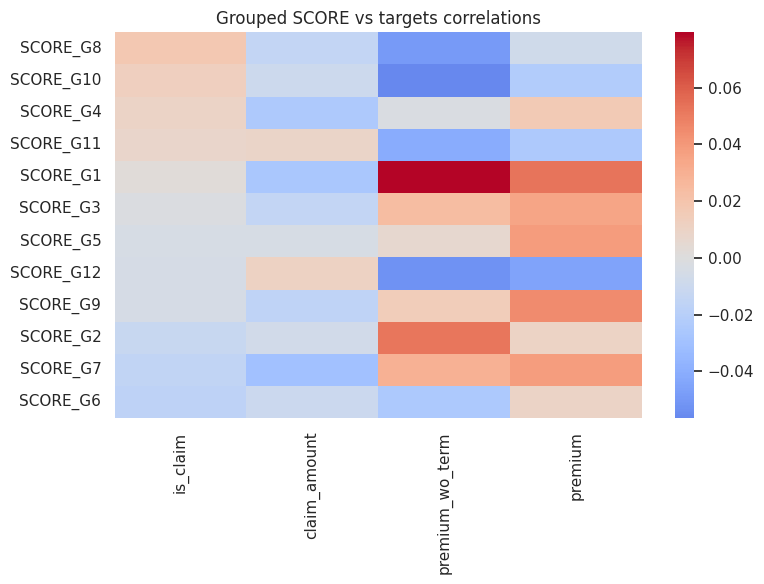

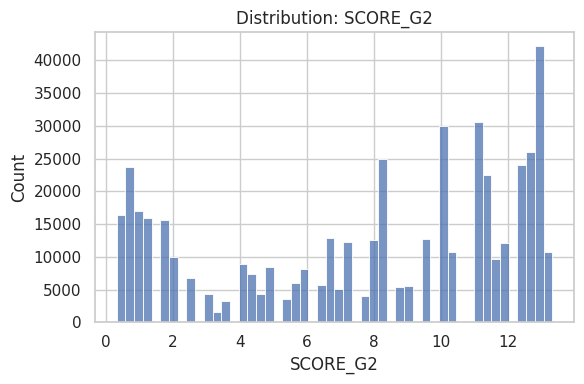

In [8]:
import re

if score_cols:
    group_map = {}
    for col in score_cols:
        match = re.match(r"SCORE_(\d+)_", col)
        if match:
            group = match.group(1)
            group_map.setdefault(group, []).append(col)

    group_means = pd.DataFrame(index=df.index)
    for group, cols in sorted(group_map.items(), key=lambda x: int(x[0])):
        group_means[f"SCORE_G{group}"] = df[cols].mean(axis=1)

    display(group_means.describe().T.sort_values("std", ascending=False).head(10))

    if targets:
        group_corr = pd.concat([group_means, df[targets]], axis=1).corr()
        corr_view = group_corr.loc[group_means.columns, targets].sort_values(by=targets[0], ascending=False)
        display(corr_view.head(15))

        plt.figure(figsize=(8, 6))
        sns.heatmap(corr_view, cmap="coolwarm", center=0)
        plt.title("Grouped SCORE vs targets correlations")
        plt.tight_layout()

    top_group = group_means.var().sort_values(ascending=False).index[0]
    plt.figure(figsize=(6, 4))
    sns.histplot(group_means[top_group], bins=50)
    plt.title(f"Distribution: {top_group}")
    plt.tight_layout()
else:
    print("No SCORE_* columns found")